# 06 · Validation results

The held-out years 2023–2025, scored once. Every number is read from `test_results.json`.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config
M = config.METRICS_DIR
def load(name):
    p = M / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"


In [2]:
r = load("test_results"); t = r["temporal"]
tab = pd.DataFrame({k: dict(precision_at_20=v["precision_at_k"], p20_monsoon=v["precision_at_k_monsoon"], pr_auc=v["pr_auc"], brier=v.get("brier"), major_recall=v["major"]["recall"])
                    for k, v in (("M1", t["M1"]), ("B0 persistence", t["B0_persistence"]), ("B1 history", t["B1_history"]))}).T
print("success levels:", r["success_levels"]); tab.round(4)

success levels: {'minimum': True, 'good': True, 'strong': True}


,precision_at_20,p20_monsoon,pr_auc,brier,major_recall
M1,0.4231,0.3517,0.3780,0.0414,0.2890
B0 persistence,0.0408,0.0414,0.0407,0.0517,0.0238
B1 history,0.0508,0.0379,0.0487,0.0518,0.0171


In [3]:
print("M1 − B0, all dates:", t["M1_minus_B0"]["all_dates"])
print("M1 − B0, monsoon:  ", t["M1_minus_B0"]["monsoon"])
print("spatial M1 − B0:   ", r["spatial"]["M1_minus_B0"]["all_dates"])

M1 − B0, all dates: {'mean': 0.38230769230769235, 'lo': 0.30615384615384617, 'hi': 0.4669230769230769, 'n_dates': 65, 'block': 3, 'n_boot': 4000}
M1 − B0, monsoon:   {'mean': 0.3103448275862069, 'lo': 0.17758620689655175, 'hi': 0.44487068965517257, 'n_dates': 29, 'block': 3, 'n_boot': 4000}
spatial M1 − B0:    {'mean': 0.3123076923076923, 'lo': 0.23769230769230767, 'hi': 0.3984615384615384, 'n_dates': 65, 'block': 3, 'n_boot': 4000}


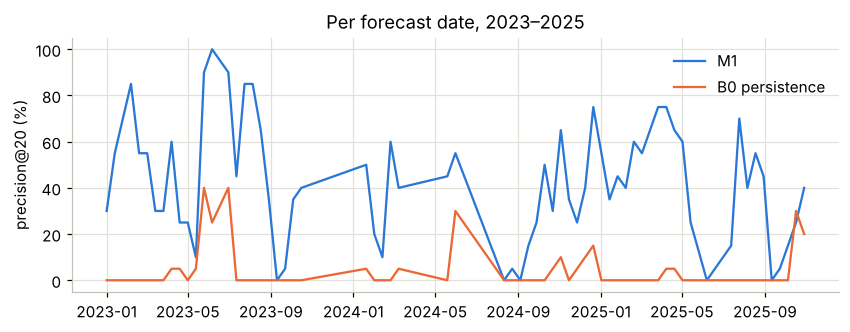

In [4]:
pd_ = pd.DataFrame(t["M1_minus_B0"]["per_date"]); pd_["date"] = pd.to_datetime(pd_.date)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(pd_.date, pd_.model * 100, color=C1, lw=1.5, label="M1")
ax.plot(pd_.date, pd_.baseline * 100, color=C2, lw=1.5, label="B0 persistence")
ax.set_ylabel("precision@20 (%)"); ax.legend(frameon=False); ax.set_title("Per forecast date, 2023–2025")
plt.show()

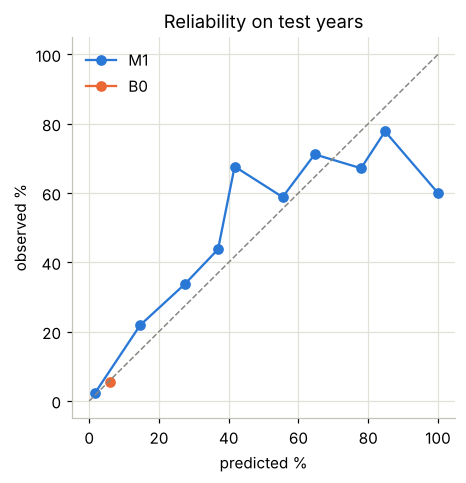

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
for name, c in (("reliability_M1", C1), ("reliability_B0", C2)):
    rr = pd.DataFrame(t[name]); ax.plot(rr.mean_pred * 100, rr.observed * 100, marker="o", color=c, lw=1.5, label=name.split("_")[1])
ax.plot([0, 100], [0, 100], ls="--", color="#898781", lw=1); ax.set_xlabel("predicted %"); ax.set_ylabel("observed %")
ax.legend(frameon=False); ax.set_title("Reliability on test years"); plt.show()

In [6]:
pd.DataFrame({y: dict(M1=v["M1"]["precision_at_k"], B0=v["B0"]["precision_at_k"]) for y, v in t["per_year"].items()}).T.round(3)

,M1,B0
2023,0.502,0.050
2024,0.339,0.058
2025,0.409,0.027


## Misses

The largest test-year retreats that the model did not put in its top 20.

In [7]:
pred = pd.read_parquet(config.PROCESSED / "models/test_predictions.parquet") if (config.PROCESSED / "models/test_predictions.parquet").exists() else pd.concat([pd.read_parquet(p) for p in sorted(config.DEMO_DIR.glob("predictions_202[345].parquet"))])
rk = "rank" if "rank" in pred else None
if rk is None:
    pred["rank"] = pred.groupby("forecast_date")["M1"].rank(ascending=False)
miss = pred[(pred.y == 1) & (pred["rank"] > 20)].sort_values("retreat_m", ascending=False)
miss[["transect_id", "forecast_date", "retreat_m", "rank", "ret_84_m", "raw_last_change_m"]].head(10)

,transect_id,forecast_date,retreat_m,rank,ret_84_m,raw_last_change_m
9177,W-52500,2023-05-25,2665.0,226.0,0.0,0.0
9824,W-52500,2023-06-06,2665.0,239.0,0.0,0.0
9178,W-52700,2023-05-25,2525.0,243.0,0.0,0.0
9825,W-52700,2023-06-06,2525.0,265.0,0.0,0.0
9179,W-52900,2023-05-25,2440.0,269.0,0.0,0.0
9826,W-52900,2023-06-06,2440.0,322.0,0.0,0.0
9176,W-52300,2023-05-25,2330.0,267.0,0.0,0.0
9823,W-52300,2023-06-06,2330.0,297.0,0.0,-10.0
9827,W-53100,2023-06-06,2315.0,314.0,0.0,0.0
9180,W-53100,2023-05-25,2315.0,286.0,0.0,0.0
